# AML23703 – Quantum Computing

## Tutorial 8: Deutsch–Jozsa Algorithm

**Name:** LAASYA S D

**USN:** 1GA23AI021

**Department:** Artificial Intelligence and Machine Learning

**Semester:** VII

**Course Code:** AML23703

**Date:** 17-09-2026

# Objective

The objective of this tutorial is to understand and implement the Deutsch–Jozsa algorithm for determining whether a Boolean function is constant or balanced.

The tutorial explores constant and balanced oracles, generalisation to different numbers of input qubits, classical versus quantum query complexity, and randomized balanced oracle generation.

# Theory

The Deutsch–Jozsa algorithm determines whether a Boolean function is either constant or balanced.

A constant function produces the same output for every possible input:

f(x) = 0 for all x

or

f(x) = 1 for all x

A balanced function produces 0 for exactly half of the possible inputs and 1 for the other half.

For n input qubits, there are:

2^n

possible input values.

Therefore, a balanced function produces:

2^(n-1) outputs of 0

and

2^(n-1) outputs of 1.

The Deutsch–Jozsa algorithm uses quantum superposition, an oracle, phase kickback, and interference to determine whether the function is constant or balanced.

The measurement of the input register gives:

All zeros → Constant

Any non-zero result → Balanced

The algorithm can determine the result with one oracle query, provided that the function is guaranteed to be either constant or balanced.

# Exercise 1: Easy

## Question

Implement a constant-function oracle for 3 input qubits and verify that the Deutsch–Jozsa algorithm produces an all-zero measurement result.

## Aim

To implement a constant oracle for 3 input qubits and verify that the Deutsch–Jozsa algorithm correctly identifies the function as constant.

## Theory

For 3 input qubits, there are:

2^3 = 8

possible input combinations.

For a constant function f(x) = 0, the function produces output 0 for all 8 possible inputs.

The Deutsch–Jozsa algorithm initializes the input qubits in superposition and uses an additional target qubit for the oracle.

For a constant oracle f(x) = 0, no operation is required on the target qubit because the output remains unchanged.

After the oracle and final Hadamard gates, a constant function produces the all-zero state:

000

Therefore:

000 → Constant

Any non-zero result would indicate a balanced function.

In [ ]:
import sys
!{sys.executable} -m pip install qiskit qiskit-aer matplotlib

In [2]:
import sys
!{sys.executable} -m pip install qiskit-aer

  Using cached qiskit_aer-0.17.2-cp312-cp312-win_amd64.whl.metadata (8.5 kB)
Using cached qiskit_aer-0.17.2-cp312-cp312-win_amd64.whl (9.6 MB)


In [3]:
import sys
!{sys.executable} -m pip install pylatexenc

  Using cached pylatexenc-2.11-py2.py3-none-any.whl.metadata (3.9 kB)
Using cached pylatexenc-2.11-py2.py3-none-any.whl (137 kB)


Deutsch-Jozsa Algorithm - Constant Function
Number of input qubits: 3
Function: f(x) = 0



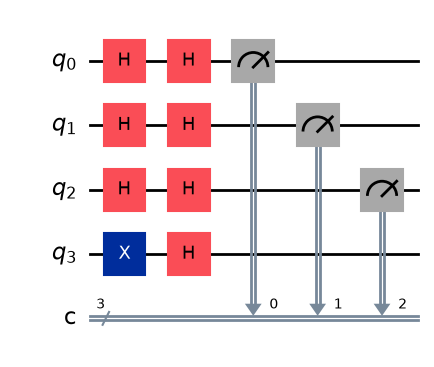

Measurement Results:
{'000': 1024}


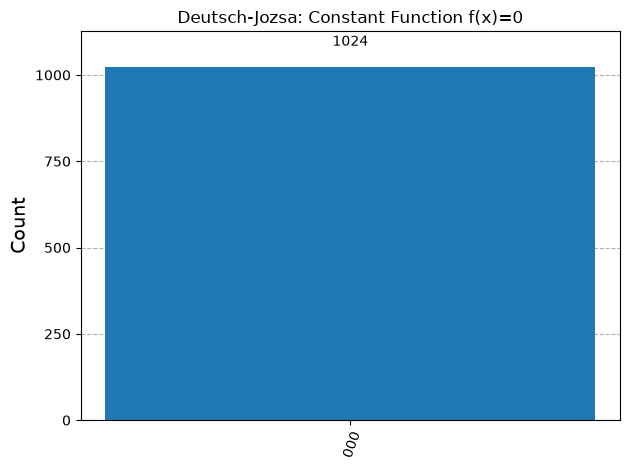

Measured Output: 000
✓ Output is 000
✓ Function is CONSTANT


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt

n = 3

qc = QuantumCircuit(n + 1, n)

qc.x(n)

for qubit in range(n + 1):
    qc.h(qubit)

# Constant oracle f(x) = 0
# No gate is required

for qubit in range(n):
    qc.h(qubit)

for qubit in range(n):
    qc.measure(qubit, qubit)

print("Deutsch-Jozsa Algorithm - Constant Function")
print("Number of input qubits:", n)
print("Function: f(x) = 0")
print()

display(qc.draw("mpl"))

simulator = AerSimulator()

compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=1024
).result()

counts = result.get_counts()

print("Measurement Results:")
print(counts)

display(
    plot_histogram(
        counts,
        title="Deutsch-Jozsa: Constant Function f(x)=0"
    )
)

measured = max(counts, key=counts.get)

print("Measured Output:", measured)

if measured == "000":
    print("✓ Output is 000")
    print("✓ Function is CONSTANT")
else:
    print("✗ Unexpected result")

# Exercise 2: Medium

## Question

Implement a balanced-function oracle for 3 input qubits using the parity function and verify that the Deutsch–Jozsa algorithm produces a non-zero measurement result.

## Aim

To implement a balanced parity-function oracle for 3 input qubits and verify that the Deutsch–Jozsa algorithm correctly identifies the function as balanced.

## Theory

The parity function for three input bits is:

f(x₁, x₂, x₃) = x₁ ⊕ x₂ ⊕ x₃

where ⊕ represents the XOR operation.

The function is balanced because exactly half of the 8 possible inputs produce 0 and the other half produce 1.

The parity oracle can be implemented using CNOT gates from each input qubit to the target qubit.

For a balanced function, the Deutsch–Jozsa algorithm produces a non-zero measurement result on the input register.

Therefore:

000 → Constant

Any non-zero result → Balanced

For the parity function, the expected measurement result is:

111

which is a non-zero result and therefore indicates a balanced function.

Deutsch-Jozsa Algorithm - Balanced Parity Function
Number of input qubits: 3
Function: f(x1,x2,x3) = x1 XOR x2 XOR x3



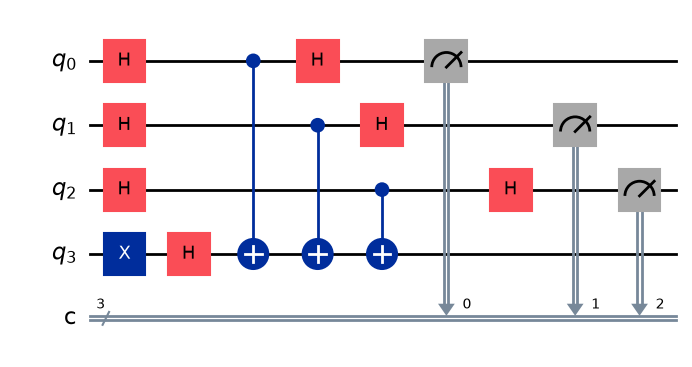

Measurement Results:
{'111': 1024}


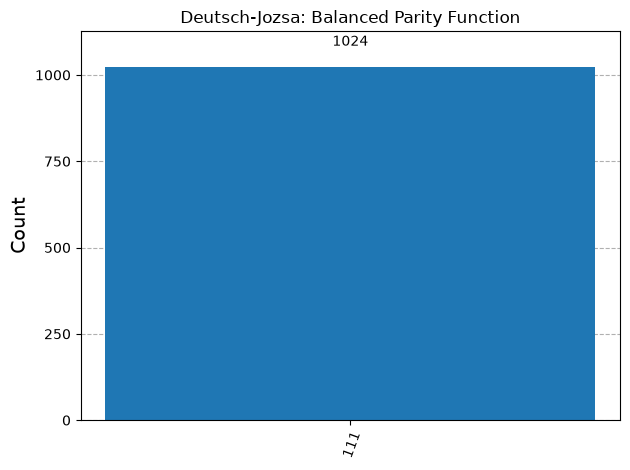

Measured Output: 111
✓ Non-zero output obtained
✓ Function is BALANCED


In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt

# Number of input qubits
n = 3

# Create circuit
# 3 input qubits + 1 target qubit
qc = QuantumCircuit(n + 1, n)

# Prepare target qubit in |1>
qc.x(n)

# Create superposition
for qubit in range(n + 1):
    qc.h(qubit)

# Balanced parity oracle
# f(x1,x2,x3) = x1 XOR x2 XOR x3
qc.cx(0, n)
qc.cx(1, n)
qc.cx(2, n)

# Apply final Hadamard gates to input qubits
for qubit in range(n):
    qc.h(qubit)

# Measure input qubits
for qubit in range(n):
    qc.measure(qubit, qubit)

# Display circuit
print("Deutsch-Jozsa Algorithm - Balanced Parity Function")
print("Number of input qubits:", n)
print("Function: f(x1,x2,x3) = x1 XOR x2 XOR x3")
print()

display(qc.draw("mpl"))

# Run simulation
simulator = AerSimulator()

compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=1024
).result()

counts = result.get_counts()

print("Measurement Results:")
print(counts)

# Display histogram
display(
    plot_histogram(
        counts,
        title="Deutsch-Jozsa: Balanced Parity Function"
    )
)

# Verification
measured = max(counts, key=counts.get)

print("Measured Output:", measured)

if measured != "000":
    print("✓ Non-zero output obtained")
    print("✓ Function is BALANCED")
else:
    print("✗ Unexpected result")

## Observation

The Deutsch–Jozsa algorithm produced the measurement result `111` for all 1024 shots.

Since the result is non-zero, the function is identified as balanced.

The parity function produces different outputs for equal halves of the possible input combinations.

## Visualization

The histogram shows that the measurement outcome is concentrated at `111`.

## Conclusion

A balanced parity-function oracle for 3 input qubits was successfully implemented using three CNOT gates.

The Deutsch–Jozsa algorithm produced the non-zero result `111`, correctly identifying the parity function as balanced.

# Exercise 3: Hard

## Question

Generalise the Deutsch–Jozsa algorithm to accept n as a parameter, where n ranges from 2 to 5, and automatically construct oracles for both constant and balanced cases.

## Aim

To develop a parameterised implementation of the Deutsch–Jozsa algorithm that can work with different numbers of input qubits and automatically construct both constant and balanced oracles.

## Theory

The Deutsch–Jozsa algorithm can be generalised to any number of input qubits.

For n input qubits, the circuit requires:

n input qubits + 1 target qubit

The constant oracle f(x) = 0 does not require any operation on the target qubit.

For the balanced case, a parity function can be used:

f(x₁, x₂, ..., xₙ) = x₁ ⊕ x₂ ⊕ ... ⊕ xₙ

The parity oracle is constructed using a CNOT gate from every input qubit to the target qubit.

The algorithm should produce:

000...0 → Constant

Any non-zero result → Balanced

This exercise tests the implementation for n = 2, 3, 4, and 5.

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt


# -------------------------------------------------
# Generic Deutsch-Jozsa Oracle
# -------------------------------------------------

def create_oracle(n, function_type):

    oracle = QuantumCircuit(n + 1)

    # Constant function f(x) = 0
    if function_type == "constant":
        pass

    # Balanced parity function
    elif function_type == "balanced":
        for qubit in range(n):
            oracle.cx(qubit, n)

    else:
        raise ValueError("Function type must be 'constant' or 'balanced'")

    return oracle


# -------------------------------------------------
# Generic Deutsch-Jozsa Algorithm
# -------------------------------------------------

def deutsch_jozsa(n, function_type, shots=1024):

    qc = QuantumCircuit(n + 1, n)

    # Prepare target qubit in |1>
    qc.x(n)

    # Create superposition
    for qubit in range(n + 1):
        qc.h(qubit)

    # Add selected oracle
    oracle = create_oracle(n, function_type)
    qc.compose(oracle, inplace=True)

    # Apply final Hadamard gates to input qubits
    for qubit in range(n):
        qc.h(qubit)

    # Measure input qubits
    for qubit in range(n):
        qc.measure(qubit, qubit)

    # Run simulation
    simulator = AerSimulator()

    compiled = transpile(qc, simulator)

    result = simulator.run(
        compiled,
        shots=shots
    ).result()

    counts = result.get_counts()

    return qc, counts


# -------------------------------------------------
# Test n = 2 to 5
# -------------------------------------------------

for n in range(2, 6):

    print("\n" + "=" * 50)
    print("Number of input qubits:", n)

    # Constant case
    qc_constant, counts_constant = deutsch_jozsa(
        n,
        "constant"
    )

    constant_result = max(
        counts_constant,
        key=counts_constant.get
    )

    print("\nConstant Function:")
    print("Measurement:", counts_constant)
    print("Result:", constant_result)

    if constant_result == "0" * n:
        print("✓ Correctly identified as CONSTANT")
    else:
        print("✗ Incorrect result")

    # Balanced case
    qc_balanced, counts_balanced = deutsch_jozsa(
        n,
        "balanced"
    )

    balanced_result = max(
        counts_balanced,
        key=counts_balanced.get
    )

    print("\nBalanced Parity Function:")
    print("Measurement:", counts_balanced)
    print("Result:", balanced_result)

    if balanced_result != "0" * n:
        print("✓ Correctly identified as BALANCED")
    else:
        print("✗ Incorrect result")


Number of input qubits: 2

Constant Function:
Measurement: {'00': 1024}
Result: 00
✓ Correctly identified as CONSTANT

Balanced Parity Function:
Measurement: {'11': 1024}
Result: 11
✓ Correctly identified as BALANCED

Number of input qubits: 3

Constant Function:
Measurement: {'000': 1024}
Result: 000
✓ Correctly identified as CONSTANT

Balanced Parity Function:
Measurement: {'111': 1024}
Result: 111
✓ Correctly identified as BALANCED

Number of input qubits: 4

Constant Function:
Measurement: {'0000': 1024}
Result: 0000
✓ Correctly identified as CONSTANT

Balanced Parity Function:
Measurement: {'1111': 1024}
Result: 1111
✓ Correctly identified as BALANCED

Number of input qubits: 5

Constant Function:
Measurement: {'00000': 1024}
Result: 00000
✓ Correctly identified as CONSTANT

Balanced Parity Function:
Measurement: {'11111': 1024}
Result: 11111
✓ Correctly identified as BALANCED


Deutsch-Jozsa Algorithm
Function: Balanced Parity
Number of input qubits: 5
Measurement Results: {'11111': 1024}


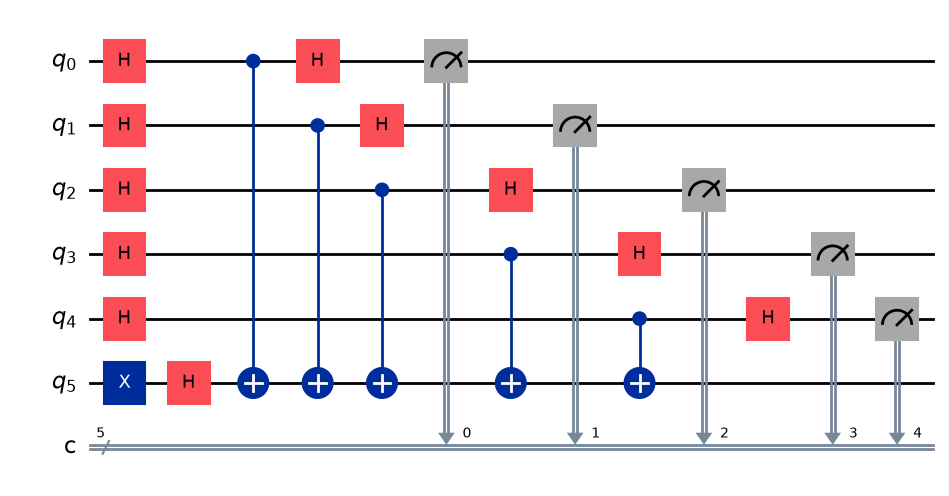

In [4]:
# Display the balanced oracle for n = 5

n = 5

qc, counts = deutsch_jozsa(
    n,
    "balanced"
)

print("Deutsch-Jozsa Algorithm")
print("Function: Balanced Parity")
print("Number of input qubits:", n)
print("Measurement Results:", counts)

display(qc.draw("mpl"))

## Observation

The generalized Deutsch–Jozsa implementation successfully handled different numbers of input qubits from n = 2 to n = 5.

For the constant oracle, the measurement result was always the all-zero state.

For the balanced parity oracle, the measurement result was non-zero.

The number of input qubits was controlled using the parameter n, allowing the same implementation to construct circuits of different sizes.

## Visualization

The generated quantum circuit for n = 5 is displayed above.

The circuit contains five input qubits and one additional target qubit.

## Conclusion

The Deutsch–Jozsa algorithm was successfully generalized using a parameter n.

The implementation automatically constructed constant and balanced parity oracles for n = 2, 3, 4, and 5.

The results verified that an all-zero measurement identifies a constant function, while a non-zero measurement identifies a balanced function.

# Exercise 4: Real-world Application

## Question

Plot the classical worst-case query count versus the quantum query count for n = 2 to 10 to visually demonstrate the exponential gap.

## Aim

To compare the classical worst-case number of oracle queries with the quantum query count required by the Deutsch–Jozsa algorithm.

## Theory

For n input bits, there are 2^n possible inputs.

In the classical deterministic approach, the worst case requires checking:

2^(n-1) + 1

inputs to determine whether a promised function is constant or balanced.

The Deutsch–Jozsa algorithm can determine the result using a single oracle query, provided that the function is guaranteed to be either constant or balanced.

Therefore:

Classical worst case = 2^(n-1) + 1

Quantum = 1

As n increases, the classical query requirement grows exponentially, while the quantum query requirement remains constant.

This demonstrates the query-complexity advantage of the Deutsch–Jozsa algorithm.

Query Complexity Comparison

n = 2: Classical = 3, Quantum = 1
n = 3: Classical = 5, Quantum = 1
n = 4: Classical = 9, Quantum = 1
n = 5: Classical = 17, Quantum = 1
n = 6: Classical = 33, Quantum = 1
n = 7: Classical = 65, Quantum = 1
n = 8: Classical = 129, Quantum = 1
n = 9: Classical = 257, Quantum = 1
n = 10: Classical = 513, Quantum = 1


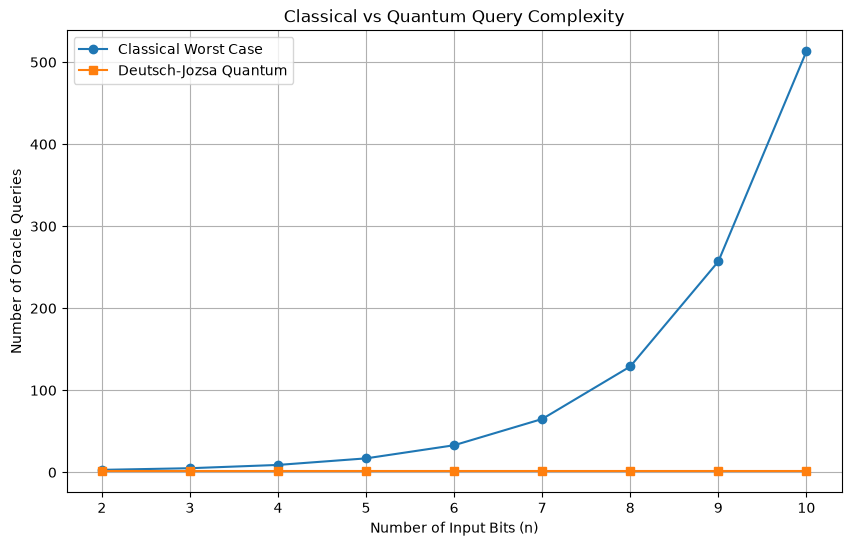

In [5]:
import matplotlib.pyplot as plt

# Values of n
n_values = list(range(2, 11))

# Classical worst-case query count
classical_queries = [
    2 ** (n - 1) + 1
    for n in n_values
]

# Deutsch-Jozsa quantum query count
quantum_queries = [
    1
    for n in n_values
]

# Display values
print("Query Complexity Comparison")
print()

for n, classical, quantum in zip(
    n_values,
    classical_queries,
    quantum_queries
):
    print(
        f"n = {n}: "
        f"Classical = {classical}, "
        f"Quantum = {quantum}"
    )

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    n_values,
    classical_queries,
    marker="o",
    label="Classical Worst Case"
)

plt.plot(
    n_values,
    quantum_queries,
    marker="s",
    label="Deutsch-Jozsa Quantum"

)

plt.xlabel("Number of Input Bits (n)")
plt.ylabel("Number of Oracle Queries")
plt.title(
    "Classical vs Quantum Query Complexity"
)

plt.xticks(n_values)
plt.legend()
plt.grid(True)

plt.show()

## Observation

The classical worst-case query count increases exponentially as the number of input bits increases.

For n = 2, the classical worst case requires 3 queries, while for n = 10 it requires 513 queries.

In comparison, Deutsch–Jozsa requires only 1 oracle query for all values of n under the constant-or-balanced promise.

## Visualization

The plot shows that the classical query count increases rapidly with n, while the quantum query count remains constant at 1.

This creates an exponential gap in query complexity.

## Conclusion

The comparison demonstrates the query-complexity advantage of the Deutsch–Jozsa algorithm.

As the number of input bits increases, the classical worst-case query requirement grows exponentially, whereas the quantum algorithm requires only one oracle query when the promise condition is satisfied.

# Exercise 5: Challenge

## Question

Implement a randomized oracle generator that randomly selects a balanced Boolean function for a given number of input qubits and verify that the Deutsch–Jozsa algorithm correctly classifies the function every time.

## Aim

To generate random balanced Boolean functions for different numbers of input qubits and verify that the Deutsch–Jozsa algorithm correctly identifies them as balanced.

## Theory

For n input qubits, there are 2^n possible input combinations.

A balanced Boolean function must produce:

2^(n-1) outputs of 0

and

2^(n-1) outputs of 1.

The randomized oracle generator creates a random balanced truth table by randomly selecting exactly half of the possible inputs to produce output 1.

The corresponding oracle is then constructed using multi-controlled X gates.

The Deutsch–Jozsa algorithm is executed for each randomly generated balanced function.

Since the generated function is guaranteed to be balanced, the measurement result should be non-zero.

This experiment verifies that Deutsch–Jozsa can correctly classify different randomly generated balanced functions.

In [6]:
import random
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt


# -------------------------------------------------
# Generate a random balanced truth table
# -------------------------------------------------

def generate_balanced_function(n):

    total_inputs = 2 ** n
    half = total_inputs // 2

    outputs = [0] * half + [1] * half

    random.shuffle(outputs)

    return outputs


# -------------------------------------------------
# Create oracle from a truth table
# -------------------------------------------------

def create_random_balanced_oracle(n, truth_table):

    oracle = QuantumCircuit(n + 1)

    for input_value, output in enumerate(truth_table):

        if output == 1:

            binary = format(input_value, f"0{n}b")

            # Convert 0-controls using X gates
            for qubit, bit in enumerate(reversed(binary)):
                if bit == "0":
                    oracle.x(qubit)

            # Multi-controlled X
            controls = list(range(n))
            target = n

            oracle.mcx(controls, target)

            # Undo X gates
            for qubit, bit in enumerate(reversed(binary)):
                if bit == "0":
                    oracle.x(qubit)

    return oracle


# -------------------------------------------------
# Run Deutsch-Jozsa algorithm
# -------------------------------------------------

def run_random_balanced_deutsch_jozsa(n, truth_table):

    qc = QuantumCircuit(n + 1, n)

    # Prepare target qubit in |1>
    qc.x(n)

    # Create superposition
    for qubit in range(n + 1):
        qc.h(qubit)

    # Add random balanced oracle
    oracle = create_random_balanced_oracle(
        n,
        truth_table
    )

    qc.compose(oracle, inplace=True)

    # Apply final Hadamard gates
    for qubit in range(n):
        qc.h(qubit)

    # Measure input qubits
    for qubit in range(n):
        qc.measure(qubit, qubit)

    # Run simulator
    simulator = AerSimulator()

    compiled = transpile(qc, simulator)

    result = simulator.run(
        compiled,
        shots=1024
    ).result()

    counts = result.get_counts()

    return qc, counts


# -------------------------------------------------
# Test randomized balanced functions
# -------------------------------------------------

n = 3
number_of_tests = 5

print("Randomized Balanced Oracle Testing")
print("Number of input qubits:", n)
print()

all_correct = True

for test in range(1, number_of_tests + 1):

    truth_table = generate_balanced_function(n)

    qc, counts = run_random_balanced_deutsch_jozsa(
        n,
        truth_table
    )

    measured = max(counts, key=counts.get)

    print("Test", test)
    print("Truth Table:", truth_table)
    print("Measurement:", counts)
    print("Measured Result:", measured)

    if measured != "0" * n:
        print("✓ Correctly identified as BALANCED")
    else:
        print("✗ Incorrect classification")
        all_correct = False

    print()


if all_correct:
    print("✓ All randomized balanced functions were correctly classified.")
else:
    print("✗ One or more tests failed.")

Randomized Balanced Oracle Testing
Number of input qubits: 3

Test 1
Truth Table: [0, 0, 1, 1, 1, 1, 0, 0]
Measurement: {'110': 1024}
Measured Result: 110
✓ Correctly identified as BALANCED

Test 2
Truth Table: [0, 1, 1, 0, 1, 0, 0, 1]
Measurement: {'111': 1024}
Measured Result: 111
✓ Correctly identified as BALANCED

Test 3
Truth Table: [0, 0, 1, 1, 1, 0, 1, 0]
Measurement: {'110': 266, '101': 260, '010': 262, '001': 236}
Measured Result: 110
✓ Correctly identified as BALANCED

Test 4
Truth Table: [1, 0, 0, 1, 0, 0, 1, 1]
Measurement: {'110': 270, '111': 250, '011': 264, '010': 240}
Measured Result: 110
✓ Correctly identified as BALANCED

Test 5
Truth Table: [1, 1, 0, 1, 0, 0, 1, 0]
Measurement: {'101': 229, '110': 265, '111': 251, '100': 279}
Measured Result: 100
✓ Correctly identified as BALANCED

✓ All randomized balanced functions were correctly classified.


Random Balanced Function
Truth Table: [0, 1, 1, 0, 1, 0, 1, 0]

Oracle Circuit:


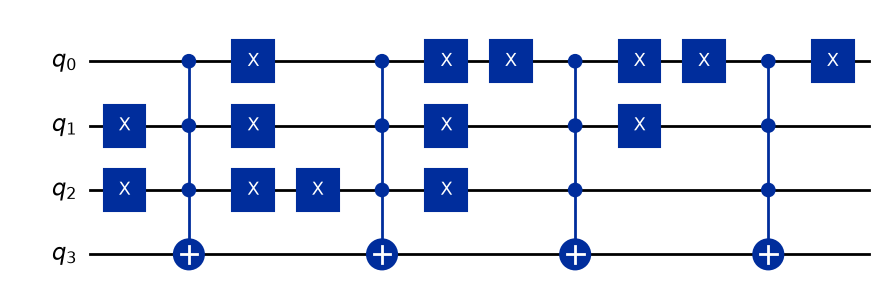

In [7]:
# Generate and display one random balanced oracle

n = 3

truth_table = generate_balanced_function(n)

oracle = create_random_balanced_oracle(
    n,
    truth_table
)

print("Random Balanced Function")
print("Truth Table:", truth_table)
print()

print("Oracle Circuit:")

display(oracle.draw("mpl"))

## Observation

The randomized oracle generator successfully generated different balanced Boolean functions.

Each generated truth table contained an equal number of 0 and 1 outputs.

The Deutsch–Jozsa algorithm produced a non-zero measurement result for each balanced function.

This confirms that the algorithm correctly classified the randomly generated functions as balanced.

## Visualization

The quantum circuit for one randomly generated balanced oracle is displayed above.

## Conclusion

A randomized balanced oracle generator was successfully implemented.

The experiment demonstrated that Deutsch–Jozsa correctly identifies different balanced functions even when the specific function is randomly generated.

# Reflection Questions

## 1. How does the promise (constant OR balanced, no other option) make a single-query guarantee possible?

The promise restricts the possible functions to only two categories: constant or balanced.

Because no other type of function is allowed, the Deutsch–Jozsa algorithm only needs to distinguish between these two possibilities.

Quantum superposition allows the oracle to process all possible input states together, and interference causes the final measurement to reveal whether the function is constant or balanced.

Therefore, under the promise condition, one oracle query is sufficient in the query-complexity model.

## 2. What would happen if a function were neither strictly constant nor balanced?

If a function were neither constant nor balanced, the promise condition of the Deutsch–Jozsa algorithm would be violated.

In this situation, the interpretation of the measurement result would no longer be valid.

An all-zero result would not necessarily prove that the function is constant, and a non-zero result would not necessarily prove that it is balanced.

The Deutsch–Jozsa algorithm is specifically designed for functions that satisfy the constant-or-balanced promise.